In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('WHR2024.csv')

# Display the first few rows of the dataset
df.head()

,Country name,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
0,Finland,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


In [2]:
# Check for missing values
df.isnull().sum()

# Drop or fill missing values if necessary
df = df.dropna()  # or use df.fillna(method='ffill', inplace=True) based on your preference


In [3]:
# Identify categorical and numerical columns
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['number']).columns

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)


Categorical Columns: Index(['Country name'], dtype='object')
Numerical Columns: Index(['Ladder score', 'upperwhisker', 'lowerwhisker',
       'Explained by: Log GDP per capita', 'Explained by: Social support',
       'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')


In [5]:
# List all column names in the dataset
df.columns


Index(['Country name', 'Ladder score', 'upperwhisker', 'lowerwhisker',
       'Explained by: Log GDP per capita', 'Explained by: Social support',
       'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')

In [6]:
# For simplicity, let's categorize countries into two groups: High and Low Happiness Scores
df['Happiness Category'] = df['Ladder score'].apply(lambda x: 'High' if x >= df['Ladder score'].median() else 'Low')

# Now apply Chi-Square test
contingency_table = pd.crosstab(df['Country name'], df['Happiness Category'])

# Perform Chi-Square Test
from scipy.stats import chi2_contingency
chi2_stat, p_val, dof, ex = chi2_contingency(contingency_table)

print(f"Chi-Square Stat: {chi2_stat}, p-value: {p_val}")


Chi-Square Stat: 140.0, p-value: 0.4602489050705632


In [7]:
# Create a categorical column based on 'Explained by: Log GDP per capita'
df['GDP Category'] = df['Explained by: Log GDP per capita'].apply(lambda x: 'High GDP' if x >= df['Explained by: Log GDP per capita'].median() else 'Low GDP')

# Split the data into two groups: High GDP and Low GDP
group1 = df[df['GDP Category'] == 'High GDP']['Ladder score']
group2 = df[df['GDP Category'] == 'Low GDP']['Ladder score']

# Perform T-test
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(group1, group2)

print(f"T-Statistic: {t_stat}, p-value: {p_val}")


T-Statistic: 10.48612126496865, p-value: 2.7762254763884367e-19


In [8]:
# Categorize 'Explained by: Social support' into low, medium, high
df['Social Support Category'] = pd.qcut(df['Explained by: Social support'], q=3, labels=['Low', 'Medium', 'High'])

# Group the data by Social Support category
groups = [df[df['Social Support Category'] == level]['Ladder score'] for level in df['Social Support Category'].unique()]

# Perform ANOVA test
from scipy.stats import f_oneway
f_stat, p_val = f_oneway(*groups)

print(f"F-Statistic: {f_stat}, p-value: {p_val}")


F-Statistic: 127.10610334827003, p-value: 6.096907920316681e-32


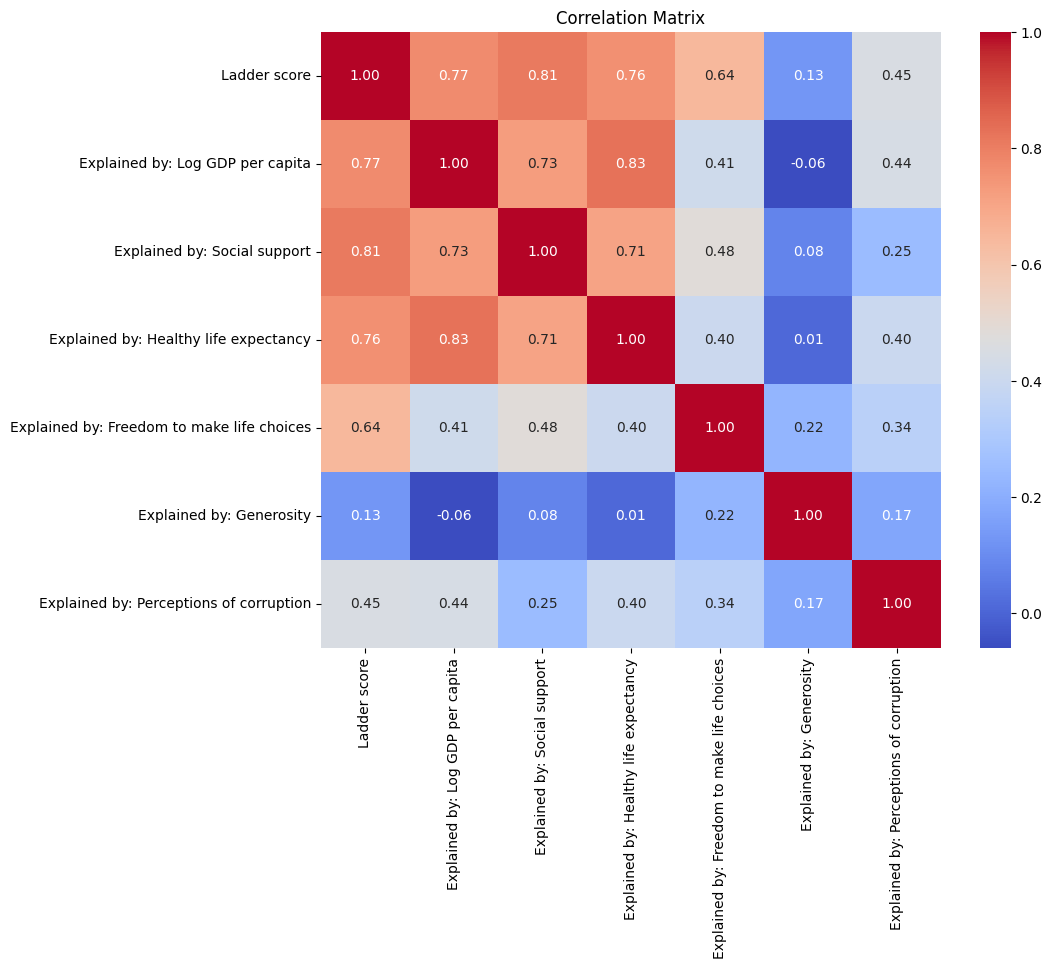

In [9]:
# Correlation matrix for numerical variables
correlation_matrix = df[['Ladder score', 'Explained by: Log GDP per capita',
                         'Explained by: Social support', 'Explained by: Healthy life expectancy',
                         'Explained by: Freedom to make life choices', 'Explained by: Generosity',
                         'Explained by: Perceptions of corruption']].corr()

import seaborn as sns
import matplotlib.pyplot as plt

# Plot the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


## Interpretation
- Chi-Square Test: A p-value below 0.05 suggests a significant association between the categorical variables.
- T-Test: A p-value below 0.05 indicates a significant difference between the two groups.
- ANOVA: A p-value below 0.05 indicates a significant difference between multiple groups.
- Correlation: A high correlation value (close to 1 or -1) suggests a strong relationship between variables.